# Overview

**Paper**: *Demand Forecasting for Rossmann Store Sales: A Weather-Enhanced Deep Learning Approach* (Qureshi et al., 2024)

**Objective**: Reproduce the benchmark deep learning results reported by Qureshi et al. (2024) using LSTM + Grid Search and GRU + Grid Search on the Rossmann Store Sales dataset.

**Principle**: Pure reproduction. The paper's methodology is followed as closely as possible without modifying it to achieve a better score.

Qureshi et al. (2024) utilized a weather-enhanced deep learning approach to predict daily sales for Rossmann stores. However, weather feature integration details are insufficient for reproduction and are recorded as a GAP.

**Key Methodology Points:**
- Clean data by removing records where stores are closed (`Open == 0`) or sales are zero.
- Join store information (`store.csv`) with transaction data (`train.csv`).
- Extract temporal features (Year, Month, Day, WeekOfYear, IsWeekend), competition features, and Promo2 features.
- Apply MinMaxScaler normalization to features and target.
- Build per-store sequences with configurable lookback window.
- Split training and validation data chronologically (80/20).
- Weather features skipped (GAP reproduction).

**Reference Metric Values:**

| Model | RMSE | MAE |
|---|---:|---:|
| LSTM + Grid Search | 635.22 | N/A |
| GRU + Grid Search | 573.54 | 369.79 |

**Reproduction Note**: Paper uses weather-enhanced features, but source data and mapping details are not available. Weather features are skipped and noted as a GAP.

# Model Architectures

# Runtime Configuration

Set `USE_GOOGLE_COLAB` below to choose the runtime:

- `False` — local / JupyterHub: load Rossmann from `data/raw/rossmann` under the project root.
- `True` — Google Colab: mount Drive and load Rossmann from the Shared Drive path used in the Colab exploration notebook.

GPU usage is detected dynamically in either mode (GPU when available, otherwise CPU).

In [3]:
# ============================================================
# Runtime toggle - set this before running setup cells below
# ============================================================
USE_GOOGLE_COLAB = True  # True = Google Colab + Shared Drive; False = local / JupyterHub

# Shared Drive path used when USE_GOOGLE_COLAB=True
COLAB_ROSSMANN_DIR = (
    '/content/drive/Shareddrives/Riset S3/Forecasting/'
    'dataset-drug-demand-prediction/rossmann'
)

print(f'USE_GOOGLE_COLAB = {USE_GOOGLE_COLAB}')
if USE_GOOGLE_COLAB:
    print(f'Colab Rossmann dir : {COLAB_ROSSMANN_DIR}')
else:
    print('Dataset will be resolved from project root: data/raw/rossmann')


USE_GOOGLE_COLAB = True
Colab Rossmann dir : /content/drive/Shareddrives/Riset S3/Forecasting/dataset-drug-demand-prediction/rossmann


# Reference-Based Exploration

Exploration adheres strictly to the methodology from Qureshi et al. (2024). Preprocessing includes loading Rossmann data, merging store information, cleaning zero-sales records, extracting temporal and competition features, applying MinMaxScaler normalization, and building per-store sequences. Modeling relies on LSTM and GRU with Grid Search. The primary evaluation metrics are RMSE and MAE.

## Preprocessing

Data loading, merging, feature engineering, scaling, and sequence building follow the Qureshi et al. methodology. Weather features are skipped due to insufficient reproduction details.

In [4]:
import os
import random
import sys
import warnings
from itertools import product
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler


import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import gc

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
sns.set_theme(style="whitegrid")

def resolve_project_root() -> Path:
    """Resolve repo root when running from notebooks/ or similar."""
    root = Path(os.getcwd()).resolve()
    if root.name.lower() in {'explore', 'notebooks', 'notebooks-to-transfers'}:
        root = root.parent
        if root.name.lower() == 'notebooks':
            root = root.parent
    return root


def configure_colab_runtime(use_google_colab: bool, colab_rossmann_dir: str):
    """Mount Drive and return Colab Rossmann dir when enabled; else None."""
    if not use_google_colab:
        return None

    try:
        from google.colab import drive
    except ImportError as exc:
        raise ImportError(
            'USE_GOOGLE_COLAB=True but google.colab is unavailable. '
            'Run this notebook in Google Colab, or set USE_GOOGLE_COLAB=False.'
        ) from exc

    drive.mount('/content/drive')
    data_dir = Path(colab_rossmann_dir)
    print('[INFO] Google Colab mode enabled.')
    print(f'[INFO] Mounted Drive; Rossmann dir -> {data_dir}')
    return data_dir


def configure_compute_device(project_root: Path) -> dict:
    """Detect GPU/CPU dynamically and print a clear training environment summary."""
    cuda_available = torch.cuda.is_available()
    compute_device = 'GPU' if cuda_available else 'CPU'
    device_name = torch.cuda.get_device_name(0) if cuda_available else 'CPU'
    device = torch.device('cuda' if cuda_available else 'cpu')

    if cuda_available:
        torch.cuda.empty_cache()
        device_message = '[INFO] GPU detected - deep learning training will use GPU acceleration.'
    else:
        device_message = '[WARN] No GPU detected - deep learning training will run on CPU (slower).'

    print('=' * 60)
    print('Compute environment')
    print('=' * 60)
    print(f'USE_GOOGLE_COLAB  : {USE_GOOGLE_COLAB}')
    print(f'Project root       : {project_root}')
    print(f'PyTorch version    : {torch.__version__}')
    print(device_message)
    print(f'Compute device     : {compute_device}')
    print(f'Device name        : {device_name}')
    print(f'CUDA devices       : {torch.cuda.device_count()}')
    print('=' * 60)

    return {
        'cuda_available': cuda_available,
        'compute_device': compute_device,
        'device_name': device_name,
        'device': device,
    }


if 'USE_GOOGLE_COLAB' not in globals():
    raise NameError('USE_GOOGLE_COLAB is not defined. Run the Runtime Configuration cell first.')

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

COLAB_DATA_DIR = configure_colab_runtime(USE_GOOGLE_COLAB, COLAB_ROSSMANN_DIR)
compute = configure_compute_device(PROJECT_ROOT)

CUDA_AVAILABLE = compute['cuda_available']
COMPUTE_DEVICE = compute['compute_device']
DEVICE_NAME = compute['device_name']
device = compute['device']
DEFAULT_BATCH_SIZE = 256

LOCAL_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'reproductions'
COLAB_OUTPUT_DIR = Path('/content/qureshi_2024_rossmann_outputs')
OUTPUT_DIR = COLAB_OUTPUT_DIR if USE_GOOGLE_COLAB else LOCAL_OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Default batch size: {DEFAULT_BATCH_SIZE}')
print(f'Output directory  : {OUTPUT_DIR}')

gc.collect()

Mounted at /content/drive
[INFO] Google Colab mode enabled.
[INFO] Mounted Drive; Rossmann dir -> /content/drive/Shareddrives/Riset S3/Forecasting/dataset-drug-demand-prediction/rossmann
Compute environment
USE_GOOGLE_COLAB  : True
Project root       : /content
PyTorch version    : 2.11.0+cu128
[INFO] GPU detected - deep learning training will use GPU acceleration.
Compute device     : GPU
Device name        : Tesla T4
CUDA devices       : 1
Default batch size: 256
Output directory  : /content/qureshi_2024_rossmann_outputs


96

In [5]:
if USE_GOOGLE_COLAB:
    DATA_DIR = COLAB_DATA_DIR if COLAB_DATA_DIR is not None else Path(COLAB_ROSSMANN_DIR)
else:
    DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'rossmann'

TRAIN_PATH = DATA_DIR / 'train.csv'
STORE_PATH = DATA_DIR / 'store.csv'

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f'train.csv not found: {TRAIN_PATH}')
if not STORE_PATH.exists():
    raise FileNotFoundError(f'store.csv not found: {STORE_PATH}')

print(f'Runtime mode   : {"Google Colab" if USE_GOOGLE_COLAB else "Local / JupyterHub"}')
print(f'Data directory : {DATA_DIR}')
print(f'Train path     : {TRAIN_PATH}')
print(f'Store path     : {STORE_PATH}')

train = pd.read_csv(TRAIN_PATH, low_memory=False, parse_dates=['Date'])
store = pd.read_csv(STORE_PATH, low_memory=False)

raw = train.merge(store, on="Store", how="left")
raw = raw.sort_values(["Store", "Date"]).reset_index(drop=True)

print(raw.shape)
raw.head()

Runtime mode   : Google Colab
Data directory : /content/drive/Shareddrives/Riset S3/Forecasting/dataset-drug-demand-prediction/rossmann
Train path     : /content/drive/Shareddrives/Riset S3/Forecasting/dataset-drug-demand-prediction/rossmann/train.csv
Store path     : /content/drive/Shareddrives/Riset S3/Forecasting/dataset-drug-demand-prediction/rossmann/store.csv
(1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,2013-01-01,0,0,0,0,a,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
4,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN


In [6]:
summary = {
    "date_min": raw["Date"].min(),
    "date_max": raw["Date"].max(),
    "n_rows": len(raw),
    "n_stores": raw["Store"].nunique(),
    "missing_cells": int(raw.isna().sum().sum()),
    "closed_rows": int((raw["Open"] == 0).sum()),
    "zero_sales_rows": int((raw["Sales"] == 0).sum()),
}
pd.Series(summary)

,0
date_min,2013-01-01 00:00:00
date_max,2015-07-31 00:00:00
n_rows,1017209
n_stores,1115
missing_cells,2173431
closed_rows,172817
zero_sales_rows,172871


### Weather Feature Gap

Paper describes a **weather-enhanced** approach, but the weather data source, join schema, and store location mapping are not explained in sufficient detail for defensible reproduction from the Rossmann Kaggle dataset.

The local Rossmann dataset only contains `train.csv`, `test.csv`, and `store.csv`. These files do not include city, coordinates, state, or store addresses. Therefore, this notebook **does not integrate weather features** and records it as a **GAP reproduction**.

This decision keeps the reproduction transparent: LSTM/GRU models are run on the non-weather Rossmann feature set that closely follows the paper, while differences from the paper's results are explained as a potential impact of the missing weather features.

### Feature Engineering

Feature set approximates the paper's Rossmann non-weather scenario: calendar, promo, holiday, store metadata, competition, and Promo2 features. Weather is excluded as a GAP reproduction.

In [7]:
def preprocess_rossmann(df, open_only=True):
    out = df.copy()
    out["Date"] = pd.to_datetime(out["Date"])

    if open_only:
        out = out[(out["Open"] == 1) & (out["Sales"] > 0)].copy()

    out["Year"] = out["Date"].dt.year
    out["Month"] = out["Date"].dt.month
    out["Day"] = out["Date"].dt.day
    out["WeekOfYear"] = out["Date"].dt.isocalendar().week.astype(int)
    out["IsWeekend"] = out["DayOfWeek"].isin([6, 7]).astype(int)

    out["CompetitionDistance"] = out["CompetitionDistance"].fillna(out["CompetitionDistance"].median())
    comp_year = out["CompetitionOpenSinceYear"].fillna(out["Year"])
    comp_month = out["CompetitionOpenSinceMonth"].fillna(out["Month"])
    out["CompetitionOpenMonths"] = (out["Year"] - comp_year) * 12 + (out["Month"] - comp_month)
    out["CompetitionOpenMonths"] = out["CompetitionOpenMonths"].clip(lower=0).fillna(0)

    out["Promo2SinceYear"] = out["Promo2SinceYear"].fillna(out["Year"])
    out["Promo2SinceWeek"] = out["Promo2SinceWeek"].fillna(out["WeekOfYear"])
    out["Promo2DurationWeeks"] = np.where(
        out["Promo2"] == 1,
        (out["Year"] - out["Promo2SinceYear"]) * 52 + (out["WeekOfYear"] - out["Promo2SinceWeek"]),
        0,
    )
    out["Promo2DurationWeeks"] = out["Promo2DurationWeeks"].clip(lower=0).fillna(0)

    month_name = out["Date"].dt.strftime("%b")
    out["IsPromo2Active"] = [
        int(promo2 == 1 and isinstance(interval, str) and month in interval.split(","))
        for promo2, interval, month in zip(out["Promo2"], out["PromoInterval"], month_name)
    ]

    drop_cols = [
        "Customers",
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "Promo2SinceWeek",
        "Promo2SinceYear",
        "PromoInterval",
    ]
    out = out.drop(columns=drop_cols, errors="ignore")

    categorical_cols = [c for c in ["StoreType", "Assortment", "StateHoliday"] if c in out.columns]
    out = pd.get_dummies(out, columns=categorical_cols, drop_first=True)
    bool_cols = out.select_dtypes(include="bool").columns
    out[bool_cols] = out[bool_cols].astype(int)

    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    fill_cols = [c for c in numeric_cols if c != "Sales"]
    out[fill_cols] = out[fill_cols].replace([np.inf, -np.inf], np.nan)
    out[fill_cols] = out[fill_cols].fillna(out[fill_cols].median(numeric_only=True)).fillna(0)

    out = out.sort_values(["Store", "Date"]).reset_index(drop=True)
    return out

prepared = preprocess_rossmann(raw, open_only=True)
prepared.shape, prepared.head()

((844338, 25),
    Store  DayOfWeek       Date  Sales  Open  Promo  SchoolHoliday  \
 0      1          3 2013-01-02   5530     1      0              1   
 1      1          4 2013-01-03   4327     1      0              1   
 2      1          5 2013-01-04   4486     1      0              1   
 3      1          6 2013-01-05   4997     1      0              1   
 4      1          1 2013-01-07   7176     1      1              1   
 
    CompetitionDistance  Promo2  Year  ...  Promo2DurationWeeks  \
 0               1270.0       0  2013  ...                  0.0   
 1               1270.0       0  2013  ...                  0.0   
 2               1270.0       0  2013  ...                  0.0   
 3               1270.0       0  2013  ...                  0.0   
 4               1270.0       0  2013  ...                  0.0   
 
    IsPromo2Active  StoreType_b  StoreType_c  StoreType_d  Assortment_b  \
 0               0            0            1            0             0   
 1       

In [8]:
feature_cols = [c for c in prepared.columns if c not in ["Date", "Sales"]]

print(f"Jumlah fitur: {len(feature_cols)}")
print(feature_cols)

Jumlah fitur: 23
['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'CompetitionOpenMonths', 'Promo2DurationWeeks', 'IsPromo2Active', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c']


### Chronological Split & Sequence Builder

Split is based on date to ensure no future data leaks into training. Sequences are built per store so that windows do not span across different stores.

In [9]:
TEST_SIZE = 0.20
dates = np.array(sorted(prepared["Date"].unique()))
split_date = dates[int(len(dates) * (1 - TEST_SIZE))]

train_df = prepared[prepared["Date"] < split_date].copy()
test_df = prepared[prepared["Date"] >= split_date].copy()

print("Split date:", pd.Timestamp(split_date).date())
print("Train:", train_df["Date"].min().date(), "to", train_df["Date"].max().date(), train_df.shape)
print("Test :", test_df["Date"].min().date(), "to", test_df["Date"].max().date(), test_df.shape)

Split date: 2015-01-24
Train: 2013-01-01 to 2015-01-23 (669257, 25)
Test : 2015-01-24 to 2015-07-31 (175081, 25)


In [10]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df.loc[:, feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
test_df.loc[:, feature_cols] = x_scaler.transform(test_df[feature_cols])

train_df.loc[:, "Sales_scaled"] = y_scaler.fit_transform(train_df[["Sales"]])
test_df.loc[:, "Sales_scaled"] = y_scaler.transform(test_df[["Sales"]])

def make_store_sequences(df, features, target="Sales_scaled", lookback=14):
    num_samples = len(df)
    X = np.empty((num_samples, lookback, len(features)), dtype=np.float32)
    y = np.empty((num_samples,), dtype=np.float32)
    meta = []
    
    idx = 0
    for store_id, g in df.sort_values(["Store", "Date"]).groupby("Store"):
        values = g[features].to_numpy(dtype=np.float32)
        targets = g[target].to_numpy(dtype=np.float32)
        dates_g = g["Date"].to_numpy()
        for i in range(lookback, len(g)):
            X[idx] = values[i - lookback:i]
            y[idx] = targets[i]
            meta.append((store_id, dates_g[i]))
            idx += 1
    return X[:idx], y[:idx], pd.DataFrame(meta, columns=["Store", "Date"])

X_train, y_train, train_meta = make_store_sequences(train_df, feature_cols, lookback=14)
X_test, y_test, test_meta = make_store_sequences(test_df, feature_cols, lookback=14)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (653647, 14, 23) y_train: (653647,)
X_test : (159471, 14, 23) y_test : (159471,)


## Modeling

Evaluate the LSTM and GRU models using the reference preprocessing with Grid Search.

### Model Builders & Grid Search

Grid search below uses a **balanced** preset for Colab GPU: large enough for reproduction exploration, but not so heavy as to risk timeout. For a quick smoke test, enable only one combination in `GRID`.

In [11]:
GRID = {
    "lookback": [28],
    "units": [64, 128],
    "recurrent_layers": [1],
    "dense_units": [32],
    "dropout": [0.1],
    "learning_rate": [5e-4],
    "batch_size": [DEFAULT_BATCH_SIZE],
    "epochs": [40],
}

class RecurrentModel(nn.Module):
    def __init__(self, kind, input_size, units=64, recurrent_layers=1, dense_units=32, dropout=0.1):
        super().__init__()
        self.recurrent_layers = recurrent_layers
        self.kind = kind
        self.units = units
        
        rnn_layer = nn.LSTM if kind == "LSTM" else nn.GRU
        self.rnn = rnn_layer(input_size, units, num_layers=recurrent_layers, batch_first=True, dropout=dropout if recurrent_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(units, dense_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(dense_units, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

def inverse_sales(values_scaled):
    return y_scaler.inverse_transform(np.asarray(values_scaled).reshape(-1, 1)).ravel()

def score_model(model, X, y_scaled, batch_size=DEFAULT_BATCH_SIZE):
    model.eval()
    dataset = TensorDataset(torch.as_tensor(X).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for batch in loader:
            batch_x = batch[0].to(device)
            out = model(batch_x)
            preds.append(out.cpu().numpy())
    pred_scaled = np.concatenate(preds, axis=0).ravel()
    
    y_true = inverse_sales(y_scaled)
    y_pred = inverse_sales(pred_scaled)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    safe_y_true = np.where(y_true == 0, 1e-6, y_true)
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / safe_y_true) ** 2))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return {"rmse": float(rmse), "mse": float(mse), "rmspe": float(rmspe), "r2": float(r2), "mae": float(mae)}, y_true, y_pred

def run_grid_search(kind, grid, train_df, feature_cols):
    rows = []
    best = None

    for lookback, units, recurrent_layers, dense_units, dropout, learning_rate, batch_size, epochs in product(
        grid["lookback"], grid["units"], grid["recurrent_layers"], grid["dense_units"], grid["dropout"], grid["learning_rate"], grid["batch_size"], grid["epochs"]
    ):
        X_train_l, y_train_l, meta_train_l = make_store_sequences(train_df, feature_cols, lookback=lookback)

        train_dates = np.array(sorted(meta_train_l["Date"].unique()))
        val_split_date = train_dates[int(len(train_dates) * 0.85)]
        fit_mask = meta_train_l["Date"] < val_split_date
        val_mask = ~fit_mask
        X_fit, X_val = X_train_l[fit_mask], X_train_l[val_mask]
        y_fit, y_val = y_train_l[fit_mask], y_train_l[val_mask]
        del X_train_l, y_train_l
        gc.collect()

        torch.manual_seed(SEED)
        model = RecurrentModel(kind, X_fit.shape[2], units, recurrent_layers, dense_units, dropout).to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()
        
        gc.collect()
        train_dataset = TensorDataset(torch.as_tensor(X_fit).float(), torch.as_tensor(y_fit).float().unsqueeze(1))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        
        val_dataset = TensorDataset(torch.as_tensor(X_val).float(), torch.as_tensor(y_val).float().unsqueeze(1))
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        best_val_loss = float('inf')
        patience_counter = 0
        patience = 5
        best_model_state = None
        epochs_run = 0

        for epoch in range(epochs):
            model.train()
            train_loss = 0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                out = model(batch_x)
                loss = criterion(out, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item() * batch_x.size(0)
            
            train_loss /= len(train_loader.dataset)
            
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_x, batch_y in val_loader:
                    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                    out = model(batch_x)
                    loss = criterion(out, batch_y)
                    val_loss += loss.item() * batch_x.size(0)
            val_loss /= len(val_loader.dataset)
            epochs_run += 1
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                break
                
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if best_model_state is not None:
            model.load_state_dict(best_model_state)

        val_metrics, _, _ = score_model(model, X_val, y_val, batch_size=batch_size)

        params = {
            "lookback": lookback,
            "units": units,
            "recurrent_layers": recurrent_layers,
            "dense_units": dense_units,
            "dropout": dropout,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "epochs_requested": epochs,
            "epochs_run": epochs_run,
        }
        row = {
            "model": kind,
            **params,
            "val_rmse": val_metrics["rmse"],
            "val_mse": val_metrics["mse"],
            "val_rmspe": val_metrics["rmspe"],
            "val_r2": val_metrics["r2"],
            "val_mae": val_metrics["mae"],
        }
        rows.append(row)

        if best is None or row["val_rmse"] < best["row"]["val_rmse"]:
            best = {"row": row, "model": model}

        print(f"{kind} {params} | val RMSE={val_metrics['rmse']:.2f} | val RMSPE={val_metrics['rmspe']:.5f} | val R2={val_metrics['r2']:.4f} | val MAE={val_metrics['mae']:.2f}")

    return pd.DataFrame(rows).sort_values("val_rmse"), best

def evaluate_best_on_test(best, test_df, feature_cols, scorer=score_model):
    row = best["row"]
    X_test_l, y_test_l, meta_test_l = make_store_sequences(test_df, feature_cols, lookback=row["lookback"])
    test_metrics, y_true, y_pred = scorer(best["model"], X_test_l, y_test_l, batch_size=row["batch_size"])
    row.update({
        "test_rmse": test_metrics["rmse"],
        "test_mse": test_metrics["mse"],
        "test_rmspe": test_metrics["rmspe"],
        "test_r2": test_metrics["r2"],
        "test_mae": test_metrics["mae"],
    })
    best.update({"y_true": y_true, "y_pred": y_pred, "meta": meta_test_l})
    print(f"{row['model']} best validation params | test RMSE={test_metrics['rmse']:.2f} | test RMSPE={test_metrics['rmspe']:.5f} | test R2={test_metrics['r2']:.4f} | test MAE={test_metrics['mae']:.2f}")
    return best


### Model 1: LSTM + Grid Search

In [12]:
try:
    del X_train, y_train, train_meta, X_test, y_test, test_meta
    gc.collect()
except:
    pass
lstm_results, lstm_best = run_grid_search("LSTM", GRID, train_df, feature_cols)
lstm_best = evaluate_best_on_test(lstm_best, test_df, feature_cols)
lstm_results

LSTM {'lookback': 28, 'units': 64, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 17} | val RMSE=3008.88 | val RMSPE=0.50871 | val R2=0.1728 | val MAE=2105.65
LSTM {'lookback': 28, 'units': 128, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 10} | val RMSE=3061.63 | val RMSPE=0.55242 | val R2=0.1436 | val MAE=2149.78
LSTM best validation params | test RMSE=2701.36 | test RMSPE=0.41223 | test R2=0.2399 | test MAE=1914.95


,model,lookback,units,recurrent_layers,dense_units,dropout,learning_rate,batch_size,epochs_requested,epochs_run,val_rmse,val_mse,val_rmspe,val_r2,val_mae
0,LSTM,28,64,1,32,0.1,0.0005,256,40,17,3008.883680,9053381.0,0.508714,0.172824,2105.651123
1,LSTM,28,128,1,32,0.1,0.0005,256,40,10,3061.629631,9373576.0,0.552419,0.143569,2149.776367


### Model 2: GRU + Grid Search

In [13]:
gru_results, gru_best = run_grid_search("GRU", GRID, train_df, feature_cols)
gru_best = evaluate_best_on_test(gru_best, test_df, feature_cols)
gru_results

GRU {'lookback': 28, 'units': 64, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 25} | val RMSE=2914.92 | val RMSPE=0.50977 | val R2=0.2237 | val MAE=2054.35
GRU {'lookback': 28, 'units': 128, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 9} | val RMSE=3021.46 | val RMSPE=0.63044 | val R2=0.1659 | val MAE=2143.67
GRU best validation params | test RMSE=2665.89 | test RMSPE=0.41405 | test R2=0.2598 | test MAE=1898.31


,model,lookback,units,recurrent_layers,dense_units,dropout,learning_rate,batch_size,epochs_requested,epochs_run,val_rmse,val_mse,val_rmspe,val_r2,val_mae
0,GRU,28,64,1,32,0.1,0.0005,256,40,25,2914.922984,8496776.0,0.509769,0.223679,2054.347900
1,GRU,28,128,1,32,0.1,0.0005,256,40,9,3021.460078,9129221.0,0.630435,0.165895,2143.674316


## Reference Results

## Reference Results

Comparison of the reproduced results against the original paper benchmarks.

In [14]:
reference = pd.DataFrame([
    {"model": "LSTM", "paper_rmse": 635.22, "paper_mae": np.nan},
    {"model": "GRU", "paper_rmse": 573.54, "paper_mae": 369.79},
])

reproduced = pd.DataFrame([
    {"model": "LSTM", "repro_rmse": lstm_best["row"]["test_rmse"], "repro_mse": lstm_best["row"]["test_mse"], "repro_rmspe": lstm_best["row"]["test_rmspe"], "repro_r2": lstm_best["row"]["test_r2"], "repro_mae": lstm_best["row"]["test_mae"], "best_params": lstm_best["row"]},
    {"model": "GRU", "repro_rmse": gru_best["row"]["test_rmse"], "repro_mse": gru_best["row"]["test_mse"], "repro_rmspe": gru_best["row"]["test_rmspe"], "repro_r2": gru_best["row"]["test_r2"], "repro_mae": gru_best["row"]["test_mae"], "best_params": gru_best["row"]},
])

comparison = reference.merge(reproduced, on="model", how="left")
comparison["rmse_delta"] = comparison["repro_rmse"] - comparison["paper_rmse"]
comparison["rmse_pct_diff"] = comparison["rmse_delta"] / comparison["paper_rmse"] * 100
comparison["mae_delta"] = comparison["repro_mae"] - comparison["paper_mae"]
comparison["mae_pct_diff"] = comparison["mae_delta"] / comparison["paper_mae"] * 100

comparison

,model,paper_rmse,paper_mae,repro_rmse,repro_mse,repro_rmspe,repro_r2,repro_mae,best_params,rmse_delta,rmse_pct_diff,mae_delta,mae_pct_diff
0,LSTM,635.22,NaN,2701.355678,7297322.5,0.412234,0.239939,1914.953979,"{'model': 'LSTM', 'lookback': 28, 'units': 64,...",2066.135678,325.263008,NaN,NaN
1,GRU,573.54,369.79,2665.894597,7106994.0,0.414047,0.259763,1898.309448,"{'model': 'GRU', 'lookback': 28, 'units': 64, ...",2092.354597,364.814066,1528.519448,413.347967


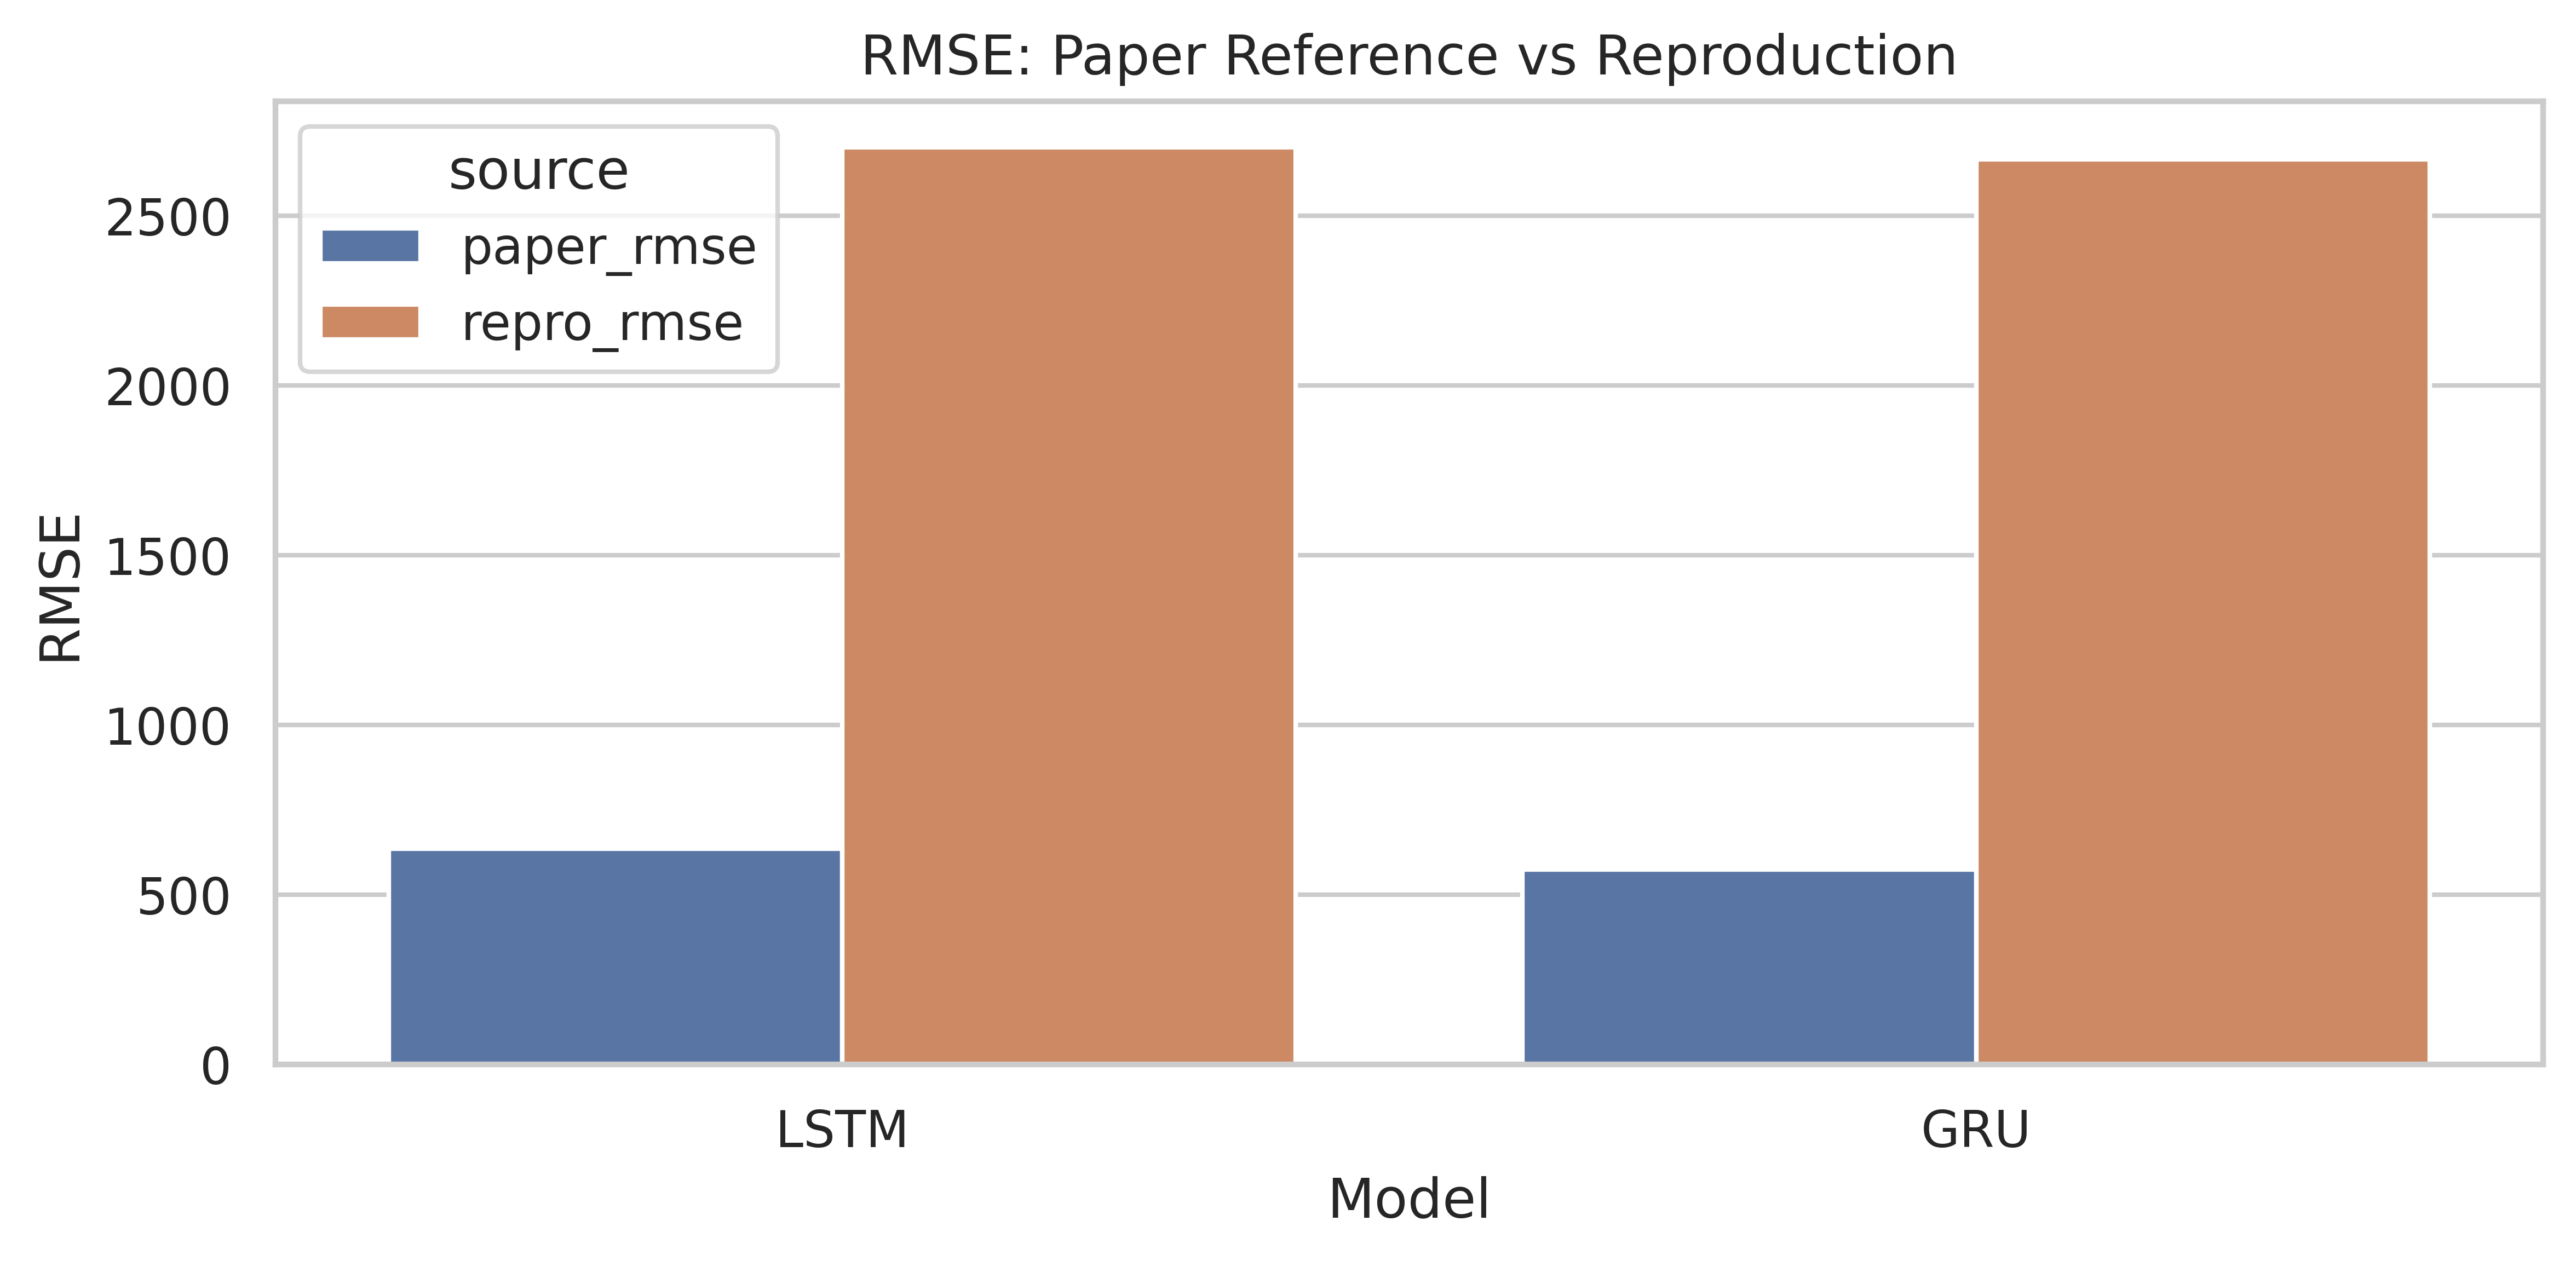

In [15]:
plot_df = comparison.melt(
    id_vars="model",
    value_vars=["paper_rmse", "repro_rmse"],
    var_name="source",
    value_name="rmse",
)

plt.figure(figsize=(8, 4), dpi=600)
sns.barplot(data=plot_df, x="model", y="rmse", hue="source")
plt.title("RMSE: Paper Reference vs Reproduction")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

## Best Baseline & Export (Reference)

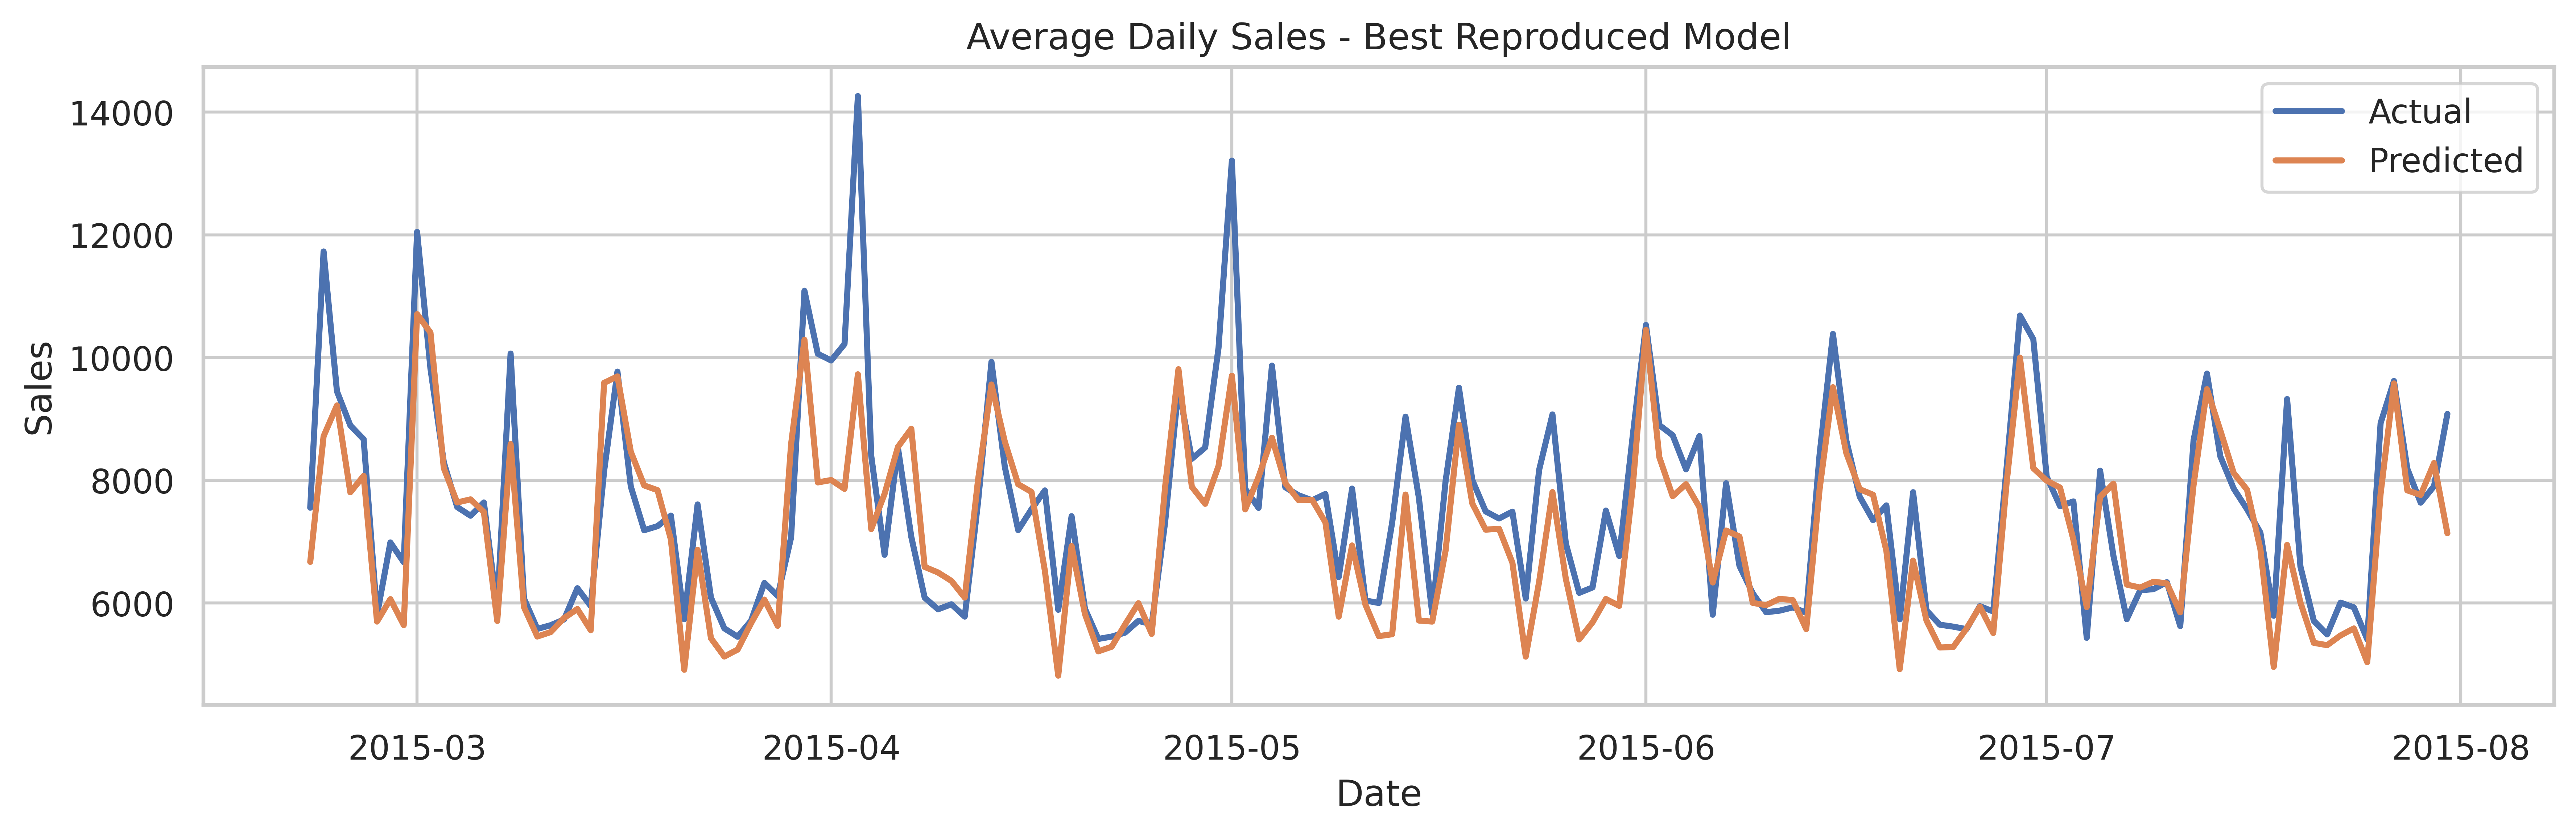

In [16]:
best_overall = gru_best if gru_best["row"]["test_rmse"] <= lstm_best["row"]["test_rmse"] else lstm_best
pred_df = best_overall["meta"].copy()
pred_df["actual"] = best_overall["y_true"]
pred_df["predicted"] = best_overall["y_pred"]

daily_pred = pred_df.groupby("Date")[["actual", "predicted"]].mean().reset_index()

plt.figure(figsize=(12, 4), dpi=600)
plt.plot(daily_pred["Date"], daily_pred["actual"], label="Actual", linewidth=2)
plt.plot(daily_pred["Date"], daily_pred["predicted"], label="Predicted", linewidth=2)
plt.title("Average Daily Sales - Best Reproduced Model")
plt.ylabel("Sales")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

# Exploration Based on Our Preprocessing

This section uses the ACF-based lag selection and rolling mean preprocessing derived from the baseline methodology to evaluate its impact on Rossmann sales prediction using the same LSTM and GRU architectures. The preprocessing adds temporal lag features and rolling means computed per store, then re-builds sequences and re-runs the identical Grid Search pipeline.

## Preprocessing

In [17]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf

print("Computing global max lag based on ACF of aggregate sales...")
df_agg = prepared.groupby("Date")["Sales"].sum().reset_index()
acf_values = acf(df_agg["Sales"], nlags=30)
lag_selected = int(np.argmax(acf_values[1:]) + 1)
print(f"Optimal global lag selected: {lag_selected}")

print("Generating lag and rolling mean features per store...")
df_features = prepared.copy()
df_features = df_features.sort_values(["Store", "Date"]).reset_index(drop=True)

for lag in range(1, lag_selected + 1):
    df_features[f"lag_{lag}"] = df_features.groupby("Store")["Sales"].shift(lag)

df_features[f"rolling_mean_{lag_selected}"] = (
    df_features.groupby("Store")["Sales"].shift(1)
    .rolling(window=lag_selected).mean()
)

df_features.dropna(subset=[f"lag_{lag_selected}", f"rolling_mean_{lag_selected}"], inplace=True)

# Build new feature column list including lag and rolling features
lag_feature_cols = [f"lag_{i}" for i in range(1, lag_selected + 1)] + [f"rolling_mean_{lag_selected}"]
feature_cols_new = feature_cols + lag_feature_cols

print(f"New feature count: {len(feature_cols_new)} (original {len(feature_cols)} + {len(lag_feature_cols)} lag/rolling)")
print("Data preparation complete.")

Computing global max lag based on ACF of aggregate sales...
Optimal global lag selected: 14
Generating lag and rolling mean features per store...
New feature count: 38 (original 23 + 15 lag/rolling)
Data preparation complete.


### Chronological Split & Sequence Builder

Identical split strategy as Reference-Based Exploration but applied to the augmented feature set.

In [18]:
# Chronological split on new features
dates_new = np.array(sorted(df_features["Date"].unique()))
split_date_new = dates_new[int(len(dates_new) * (1 - TEST_SIZE))]

train_df_new = df_features[df_features["Date"] < split_date_new].copy()
test_df_new = df_features[df_features["Date"] >= split_date_new].copy()

print("Split date (new):", pd.Timestamp(split_date_new).date())
print("Train (new):", train_df_new["Date"].min().date(), "to", train_df_new["Date"].max().date(), train_df_new.shape)
print("Test (new) :", test_df_new["Date"].min().date(), "to", test_df_new["Date"].max().date(), test_df_new.shape)

Split date (new): 2015-01-27
Train (new): 2013-01-15 to 2015-01-26 (655892, 40)
Test (new) : 2015-01-27 to 2015-07-31 (172836, 40)


In [19]:
# Scale features and target for new preprocessing
x_scaler_new = MinMaxScaler()
y_scaler_new = MinMaxScaler()

train_df_new.loc[:, feature_cols_new] = x_scaler_new.fit_transform(train_df_new[feature_cols_new])
test_df_new.loc[:, feature_cols_new] = x_scaler_new.transform(test_df_new[feature_cols_new])

train_df_new.loc[:, "Sales_scaled"] = y_scaler_new.fit_transform(train_df_new[["Sales"]])
test_df_new.loc[:, "Sales_scaled"] = y_scaler_new.transform(test_df_new[["Sales"]])

# Override inverse_sales for new scaler
def inverse_sales_new(values_scaled):
    return y_scaler_new.inverse_transform(np.asarray(values_scaled).reshape(-1, 1)).ravel()

def score_model_new(model, X, y_scaled, batch_size=DEFAULT_BATCH_SIZE):
    pred_scaled = model.predict(X, batch_size=batch_size, verbose=0).ravel()
    y_true = inverse_sales_new(y_scaled)
    y_pred = inverse_sales_new(pred_scaled)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    safe_y_true = np.where(y_true == 0, 1e-6, y_true)
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / safe_y_true) ** 2))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return {"rmse": float(rmse), "mse": float(mse), "rmspe": float(rmspe), "r2": float(r2), "mae": float(mae)}, y_true, y_pred

X_train_new, y_train_new, train_meta_new = make_store_sequences(train_df_new, feature_cols_new, lookback=14)
X_test_new, y_test_new, test_meta_new = make_store_sequences(test_df_new, feature_cols_new, lookback=14)

print("X_train (new):", X_train_new.shape, "y_train (new):", y_train_new.shape)
print("X_test (new) :", X_test_new.shape, "y_test (new) :", y_test_new.shape)

X_train (new): (640282, 14, 38) y_train (new): (640282,)
X_test (new) : (157226, 14, 38) y_test (new) : (157226,)


## Modeling

### Model Builders & Grid Search

Using the same Grid Search configuration and model architecture as Reference-Based Exploration, but with the augmented ACF-based feature set.

In [20]:
def score_model_new(model, X, y_scaled, batch_size=DEFAULT_BATCH_SIZE):
    model.eval()
    dataset = TensorDataset(torch.as_tensor(X).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for batch in loader:
            batch_x = batch[0].to(device)
            out = model(batch_x)
            preds.append(out.cpu().numpy())
    pred_scaled = np.concatenate(preds, axis=0).ravel()
    
    y_true = inverse_sales_new(y_scaled)
    y_pred = inverse_sales_new(pred_scaled)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    safe_y_true = np.where(y_true == 0, 1e-6, y_true)
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / safe_y_true) ** 2))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return {"rmse": float(rmse), "mse": float(mse), "rmspe": float(rmspe), "r2": float(r2), "mae": float(mae)}, y_true, y_pred

def run_grid_search_new(kind, grid, train_df, feature_cols):
    rows = []
    best = None

    for lookback, units, recurrent_layers, dense_units, dropout, learning_rate, batch_size, epochs in product(
        grid["lookback"], grid["units"], grid["recurrent_layers"], grid["dense_units"], grid["dropout"], grid["learning_rate"], grid["batch_size"], grid["epochs"]
    ):
        X_train_l, y_train_l, meta_train_l = make_store_sequences(train_df, feature_cols, lookback=lookback)

        train_dates = np.array(sorted(meta_train_l["Date"].unique()))
        val_split_date = train_dates[int(len(train_dates) * 0.85)]
        fit_mask = meta_train_l["Date"] < val_split_date
        val_mask = ~fit_mask
        X_fit, X_val = X_train_l[fit_mask], X_train_l[val_mask]
        y_fit, y_val = y_train_l[fit_mask], y_train_l[val_mask]
        del X_train_l, y_train_l
        gc.collect()

        torch.manual_seed(SEED)
        model = RecurrentModel(kind, X_fit.shape[2], units, recurrent_layers, dense_units, dropout).to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()
        
        gc.collect()
        train_dataset = TensorDataset(torch.as_tensor(X_fit).float(), torch.as_tensor(y_fit).float().unsqueeze(1))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        
        val_dataset = TensorDataset(torch.as_tensor(X_val).float(), torch.as_tensor(y_val).float().unsqueeze(1))
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        best_val_loss = float('inf')
        patience_counter = 0
        patience = 5
        best_model_state = None
        epochs_run = 0

        for epoch in range(epochs):
            model.train()
            train_loss = 0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                out = model(batch_x)
                loss = criterion(out, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item() * batch_x.size(0)
            
            train_loss /= len(train_loader.dataset)
            
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_x, batch_y in val_loader:
                    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                    out = model(batch_x)
                    loss = criterion(out, batch_y)
                    val_loss += loss.item() * batch_x.size(0)
            val_loss /= len(val_loader.dataset)
            epochs_run += 1
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                break
                
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if best_model_state is not None:
            model.load_state_dict(best_model_state)

        val_metrics, _, _ = score_model_new(model, X_val, y_val, batch_size=batch_size)

        params = {
            "lookback": lookback,
            "units": units,
            "recurrent_layers": recurrent_layers,
            "dense_units": dense_units,
            "dropout": dropout,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "epochs_requested": epochs,
            "epochs_run": epochs_run,
        }
        row = {
            "model": kind,
            **params,
            "val_rmse": val_metrics["rmse"],
            "val_mse": val_metrics["mse"],
            "val_rmspe": val_metrics["rmspe"],
            "val_r2": val_metrics["r2"],
            "val_mae": val_metrics["mae"],
        }
        rows.append(row)

        if best is None or row["val_rmse"] < best["row"]["val_rmse"]:
            best = {"row": row, "model": model}

        print(f"{kind} {params} | val RMSE={val_metrics['rmse']:.2f} | val RMSPE={val_metrics['rmspe']:.5f} | val R2={val_metrics['r2']:.4f} | val MAE={val_metrics['mae']:.2f}")

    return pd.DataFrame(rows).sort_values("val_rmse"), best


### Model 1: LSTM + Grid Search

In [21]:
print("Training LSTM with ACF-based preprocessing...")
try:
    del X_train_new, y_train_new, train_meta_new, X_test_new, y_test_new, test_meta_new
    gc.collect()
except:
    pass
lstm_results_new, lstm_best_new = run_grid_search_new("LSTM", GRID, train_df_new, feature_cols_new)
lstm_best_new = evaluate_best_on_test(lstm_best_new, test_df_new, feature_cols_new, scorer=score_model_new)
lstm_results_new

Training LSTM with ACF-based preprocessing...
LSTM {'lookback': 28, 'units': 64, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 7} | val RMSE=1760.58 | val RMSPE=0.50818 | val R2=0.7210 | val MAE=1256.05
LSTM {'lookback': 28, 'units': 128, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 14} | val RMSE=1580.75 | val RMSPE=0.45705 | val R2=0.7751 | val MAE=1070.70
LSTM best validation params | test RMSE=1410.69 | test RMSPE=0.23629 | test R2=0.7938 | test MAE=1012.78


,model,lookback,units,recurrent_layers,dense_units,dropout,learning_rate,batch_size,epochs_requested,epochs_run,val_rmse,val_mse,val_rmspe,val_r2,val_mae
1,LSTM,28,128,1,32,0.1,0.0005,256,40,14,1580.753776,2498782.5,0.457046,0.775085,1070.704834
0,LSTM,28,64,1,32,0.1,0.0005,256,40,7,1760.580018,3099642.0,0.508175,0.721001,1256.052368


### Model 2: GRU + Grid Search

In [22]:
print("Training GRU with ACF-based preprocessing...")
try:
    del X_train_new, y_train_new, train_meta_new, X_test_new, y_test_new, test_meta_new
    gc.collect()
except:
    pass
gru_results_new, gru_best_new = run_grid_search_new("GRU", GRID, train_df_new, feature_cols_new)
gru_best_new = evaluate_best_on_test(gru_best_new, test_df_new, feature_cols_new, scorer=score_model_new)
gru_results_new

Training GRU with ACF-based preprocessing...
GRU {'lookback': 28, 'units': 64, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 7} | val RMSE=1710.24 | val RMSPE=0.50896 | val R2=0.7367 | val MAE=1218.48
GRU {'lookback': 28, 'units': 128, 'recurrent_layers': 1, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'epochs_requested': 40, 'epochs_run': 14} | val RMSE=1589.06 | val RMSPE=0.46708 | val R2=0.7727 | val MAE=1081.40
GRU best validation params | test RMSE=1266.04 | test RMSPE=0.22955 | test R2=0.8339 | test MAE=924.49


,model,lookback,units,recurrent_layers,dense_units,dropout,learning_rate,batch_size,epochs_requested,epochs_run,val_rmse,val_mse,val_rmspe,val_r2,val_mae
1,GRU,28,128,1,32,0.1,0.0005,256,40,14,1589.063325,2525122.25,0.467081,0.772714,1081.397217
0,GRU,28,64,1,32,0.1,0.0005,256,40,7,1710.236899,2924910.25,0.508962,0.736729,1218.484009


## Best Baseline & Export (Our Preprocessing)

Best Baseline Results (Our Preprocessing):


,Model,Our Preprocessing RMSE,Our Preprocessing MSE,Our Preprocessing RMSPE,Our Preprocessing R2,Our Preprocessing MAE
1,GRU + Grid Search,1266.04,1602845.38,0.22955,0.8339,924.49
0,LSTM + Grid Search,1410.69,1990056.50,0.23629,0.7938,1012.78


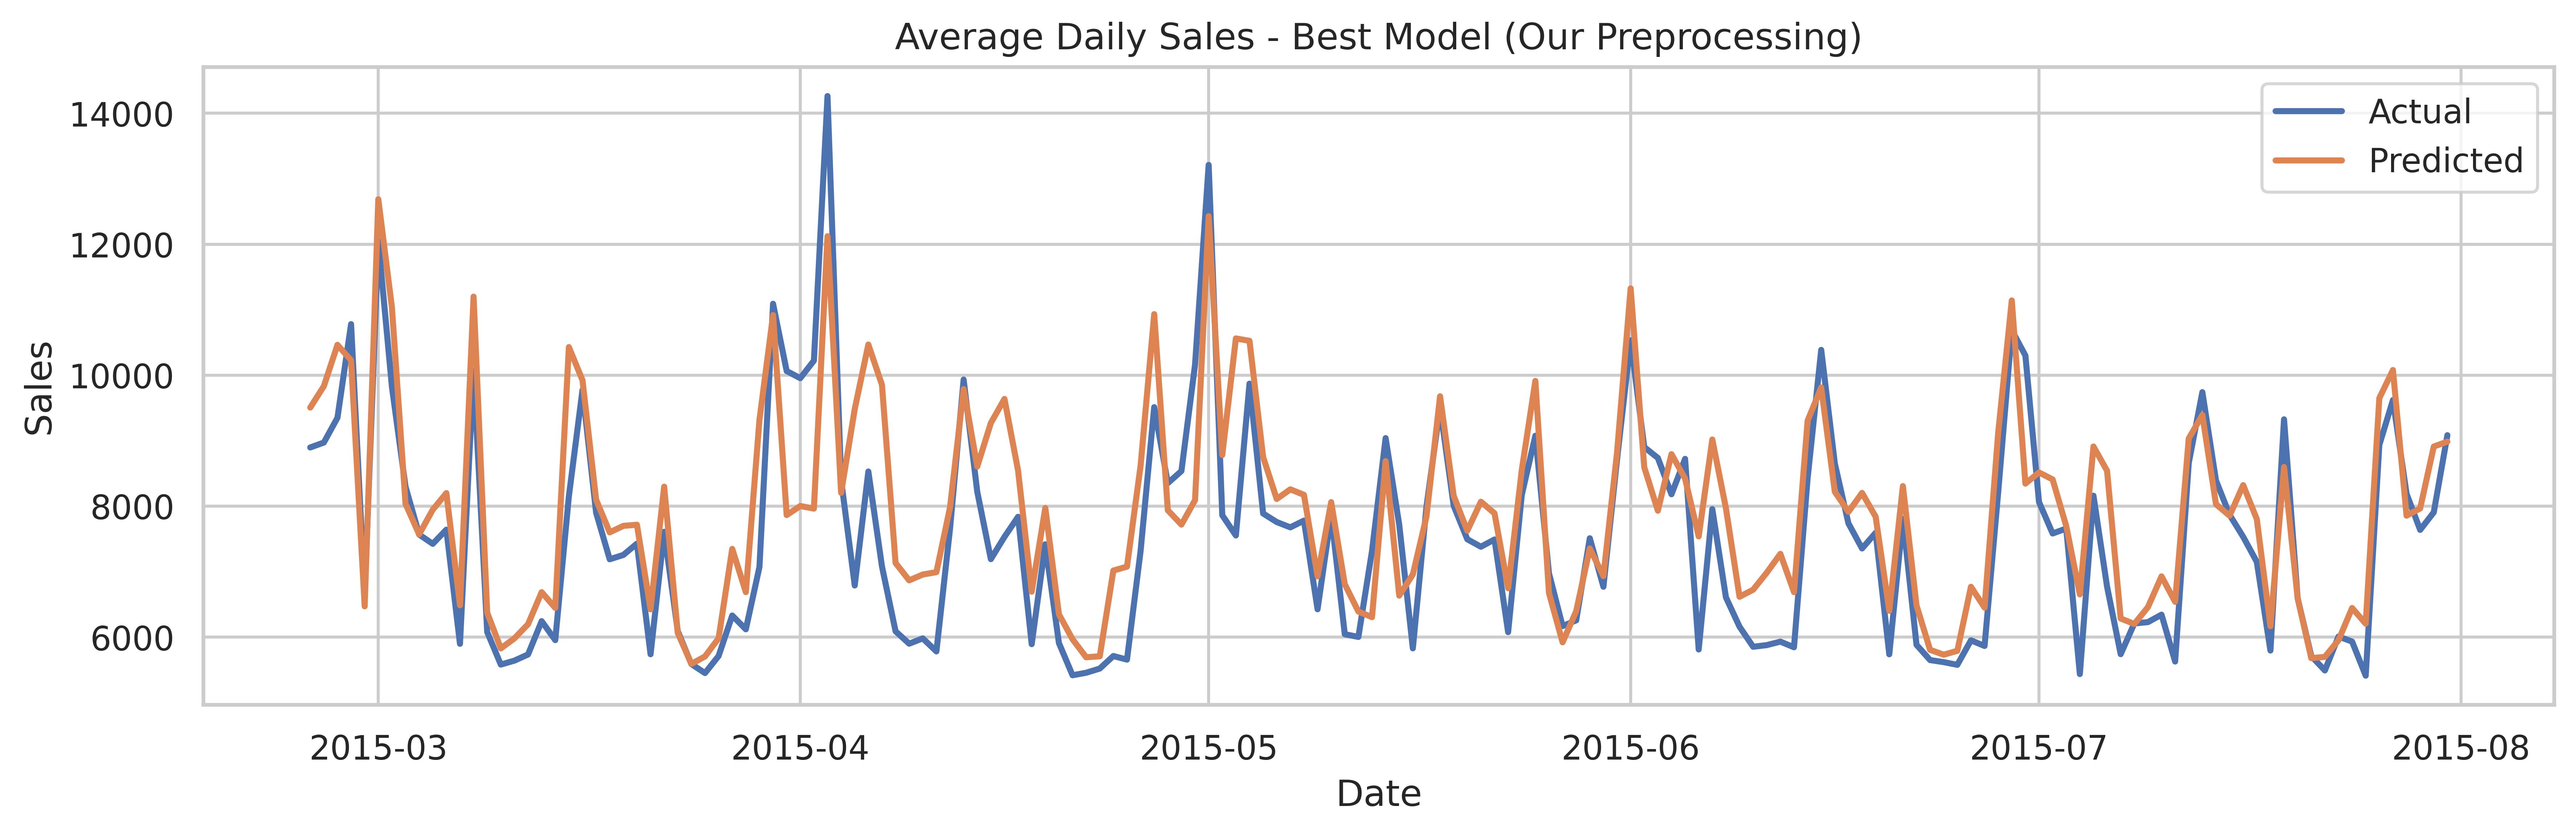

In [23]:
df_compare_new = pd.DataFrame([
    {"Model": "LSTM + Grid Search", "Our Preprocessing RMSE": round(lstm_best_new["row"]["test_rmse"], 2), "Our Preprocessing MSE": round(lstm_best_new["row"]["test_mse"], 2), "Our Preprocessing RMSPE": round(lstm_best_new["row"]["test_rmspe"], 5), "Our Preprocessing R2": round(lstm_best_new["row"]["test_r2"], 4), "Our Preprocessing MAE": round(lstm_best_new["row"]["test_mae"], 2)},
    {"Model": "GRU + Grid Search", "Our Preprocessing RMSE": round(gru_best_new["row"]["test_rmse"], 2), "Our Preprocessing MSE": round(gru_best_new["row"]["test_mse"], 2), "Our Preprocessing RMSPE": round(gru_best_new["row"]["test_rmspe"], 5), "Our Preprocessing R2": round(gru_best_new["row"]["test_r2"], 4), "Our Preprocessing MAE": round(gru_best_new["row"]["test_mae"], 2)}
])
print("Best Baseline Results (Our Preprocessing):")
display(df_compare_new.sort_values("Our Preprocessing RMSE"))

# Forecast plot for best model (Our Preprocessing)
best_overall_new = gru_best_new if gru_best_new["row"]["test_rmse"] <= lstm_best_new["row"]["test_rmse"] else lstm_best_new
pred_df_new = best_overall_new["meta"].copy()
pred_df_new["actual"] = best_overall_new["y_true"]
pred_df_new["predicted"] = best_overall_new["y_pred"]

daily_pred_new = pred_df_new.groupby("Date")[["actual", "predicted"]].mean().reset_index()

plt.figure(figsize=(12, 4), dpi=600)
plt.plot(daily_pred_new["Date"], daily_pred_new["actual"], label="Actual", linewidth=2)
plt.plot(daily_pred_new["Date"], daily_pred_new["predicted"], label="Predicted", linewidth=2)
plt.title("Average Daily Sales - Best Model (Our Preprocessing)")
plt.ylabel("Sales")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

### Visualization Actual vs Predicted (Reference)


In [ ]:
qureshi_reference_visualizations = [
    ("LSTM + Grid Search", lstm_best),
    ("GRU + Grid Search", gru_best),
]

fig, ax = plt.subplots(2, 1, figsize=(18, 15))
plt.subplots_adjust(wspace=0.1, hspace=0.3)

for idx, (model_name, result) in enumerate(qureshi_reference_visualizations):
    pred_df = result["meta"].copy()
    pred_df["actual"] = result["y_true"]
    pred_df["predicted"] = result["y_pred"]
    daily_pred = pred_df.groupby("Date")[["actual", "predicted"]].mean().reset_index()
    row = result["row"]
    ax[idx].set_title(
        f"{model_name} (Test MSE={row['test_mse']:.2f}, RMSE={row['test_rmse']:.2f})\nRMSPE={row['test_rmspe']:.5f}, R2={row['test_r2']:.4f}"
    )
    ax[idx].plot(daily_pred["Date"], daily_pred["actual"], 'r-', label='Test Actual')
    ax[idx].plot(daily_pred["Date"], daily_pred["predicted"], 'g--', label='Test Predicted')
    ax[idx].legend(loc='upper left')

plt.show()


### Visualization Actual vs Predicted (Our Preprocessing)


In [ ]:
qureshi_our_visualizations = [
    ("LSTM + Grid Search", lstm_best_new),
    ("GRU + Grid Search", gru_best_new),
]

fig, ax = plt.subplots(2, 1, figsize=(18, 15))
plt.subplots_adjust(wspace=0.1, hspace=0.3)

for idx, (model_name, result) in enumerate(qureshi_our_visualizations):
    pred_df = result["meta"].copy()
    pred_df["actual"] = result["y_true"]
    pred_df["predicted"] = result["y_pred"]
    daily_pred = pred_df.groupby("Date")[["actual", "predicted"]].mean().reset_index()
    row = result["row"]
    ax[idx].set_title(
        f"{model_name} (Test MSE={row['test_mse']:.2f}, RMSE={row['test_rmse']:.2f})\nRMSPE={row['test_rmspe']:.5f}, R2={row['test_r2']:.4f}"
    )
    ax[idx].plot(daily_pred["Date"], daily_pred["actual"], 'r-', label='Test Actual')
    ax[idx].plot(daily_pred["Date"], daily_pred["predicted"], 'g--', label='Test Predicted')
    ax[idx].legend(loc='upper left')

plt.show()


# Summary

## Experimental Setup

Two preprocessing approaches compared using the same 2 deep learning models on the Rossmann daily sales dataset:

| Aspect | Reference (Paper) | Our Preprocessing |
|--------|-------------------|-------------------|
| Split | Chronological 80/20 by date | Chronological 80/20 by date |
| Scaling | MinMaxScaler (features + target) | MinMaxScaler (features + target) |
| Sequence | Per-store lookback windows (14–28 days) | Per-store lookback windows (14–28 days) |
| Features | Calendar, Promo, Competition, Promo2 (weather GAP) | Same + ACF-based lag_n + rolling_mean |
| Hyperparameters | Grid search over units, lookback, epochs | Same grid search configuration |

## Models Evaluated

| # | Model | Type |
|---|-------|------|
| 1 | LSTM + Grid Search | Deep Learning (Recurrent) |
| 2 | GRU + Grid Search | Deep Learning (Recurrent) |

## Key Metrics

- RMSE, MSE, RMSPE, R2, and MAE are reported for comparison with the main Rossmann result table.
- The results are compared between the Reference Preprocessing and Our Preprocessing to analyze the impact of ACF-based lag and rolling mean features on deep learning forecasting.

## Key Findings

- **Deep Learning Reproduction**: The reproduced LSTM and GRU models were run without weather features (GAP reproduction). Metric differences from the paper are expected due to the missing weather-enhanced features.
- **Preprocessing Impact**: The ACF-based lag and rolling mean features (Our Preprocessing) provide temporal context directly in the input sequences. This may help the recurrent models capture short-term autocorrelation patterns more effectively than the base feature set alone.
- **Weather Feature Impact**: The absence of weather features in both preprocessing approaches means results are not fully comparable to the paper. Weather integration would require store location data not available in the Kaggle dataset.

## Limitations

- **Weather GAP**: Paper does not detail weather data source, join schema, or store location mapping. Dataset does not include store locations.
- **Customer Leakage**: The `Customers` column was excluded to prevent information leakage, as customer counts are not available at forecast time.
- **Split Differences**: If the paper uses a different split strategy, metric values may shift.
- **Grid Search Scope**: Grid search was kept compact for initial exploration. Expanding the grid may improve results.
- **Stale Hyperparameters**: The grid search parameters used in Our Preprocessing are identical to the Reference approach. Retuning specifically for the lag-augmented feature set may yield improved performance.